[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab6/lab6-parte1.ipynb)
# Práctica 6: Redes neuronales convolucionales - Parte 1 - FF vs CNN


### Pre-requisitos. Instalar paquetes

Para la primera parte de este Laboratorio 6 necesitaremos, además de torch, el módulo torchvision para cargar los datos. Además, como habitualmente, fijaremos la semilla aleatoria para asegurar la reproducibilidad de los experimentos.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import transforms
import os
import numpy as np
import random
from matplotlib import pyplot as plt

# Fijamos la semilla para reproducibilidad
seed = 1234567
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


### Carga del conjunto de datos

En esta ocasión trabajaremos con el conjunto de imágenes *mnist*, que representa dígitos escritos a mano. Debemos indicar a nuestro dataloader que haga lotes de 128 elementos.

100%|██████████| 9.91M/9.91M [00:00<00:00, 65.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.45MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


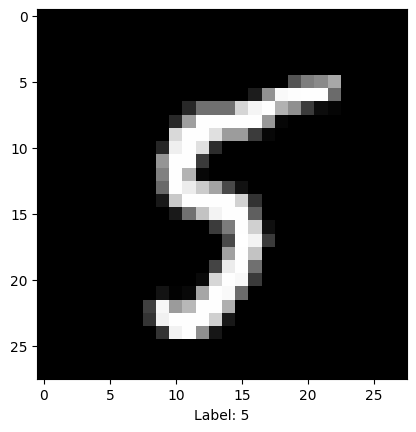

In [2]:
import torch
import torch.utils.data as data
import torchvision
from torchvision import transforms
from matplotlib import pyplot as plt

# Cargamos MNIST usando torchvision
transform = transforms.Compose([
    transforms.ToTensor(), # convierte a tensor y escala a [0,1]
])

train_val = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# TODO - Divide train_val en train y val (80/20) (usa la función data.random_split de torch)
val_size = int(len(train_val) * 0.2)
train_size = len(train_val) - val_size
train_set, val_set = data.random_split(train_val, [train_size, val_size], generator=torch.Generator().manual_seed(seed))

# TODO - Crea los DataLoaders
batch_size = 128
train_loader = data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

NUM_CLASSES = 10
IMAGE_SHAPE = (1, 28, 28)

# Para comprobar que se ha cargado tomamos un elemento y lo mostramos
im_batch, label_batch = next(iter(train_loader))
ej_imagen = im_batch[0]
plt.imshow(ej_imagen.squeeze(), cmap='gray')
plt.xlabel(f'Label: {label_batch[0].item()}')
plt.show()

## Ajustando los datos con un red neuronal feed-forward

Vamos a modelar los datos con una red feed-forward que tenga capas de 40, 25 y 16 unidades (todas con activación ReLU). Debemos tener en cuenta que las imágenes son tensores de dimensión 3 (su `shape` es (1,28,28)), mientras que la entrada de nuestras capas Dense debe ser un tensor de dimensión 1. Para adecuar la entrada a lo que necesitamos, vamos a "aplanar" los tensores de las imágenes, que pasarán de `shape` (28,28,1) a `shape` (784). Para ello aplanaremos el lote de (128,1,28,28) a (128, 784) en la función `forward`.

Por último, la salida de nuestro modelo debe tener tantas componentes como clases distintas tiene el conjunto. Como queremos que la salida aproxime la probabilidad de las distintas clases, lo habitual sería poner una función de activación *softmax*, pero en este caso, por razones de eficiencia del entrenamiento, es mejor dejar una salida lineal y posteriormente usar la función de pérdida `nn.CrossEntropyLoss` que espera las salidas vienen en ese formato.

In [3]:
class MLP(nn.Module):
    # TODO - Completa la clase siguiendo las instrucciones dadas en la celda anterior.
    def __init__(self):
        super(MLP, self).__init__()
        # Capas densas: Entrada 784 -> 40 -> 25 -> 16 -> 10 (Salida)
        self.fc1 = nn.Linear(784, 40)
        self.fc2 = nn.Linear(40, 25)
        self.fc3 = nn.Linear(25, 16)
        self.out = nn.Linear(16, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Aplanamos el lote de (batch_size, 1, 28, 28) a (batch_size, 784)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.out(x)
        return x

### Entrenamiento del modelo
Vamos a establecer la función de pérdida, el optimizador (Adam con el LR por defecto) y la métrica que nos servirá para evaluar el rendimiento del modelo entrenado (precisión categórica).

Como intentamos predecir una clase entre varias, nuestra función de pérdida debe ser la [entropía cruzada](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). Le indicaremos que la salida de nuestra red como *logits* y las etiquetas con el valor numérico de la clase (no en one-hot encoding).

In [4]:
# Evaluación sobre el conjunto de test
def evaluate(model, dataloader, loss_fn):
    # TODO - Completa la función para que devuelva la pérdida y la tasa de acierto
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy


def train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=16):
    # TODO - Completa la función para que haga el entrenamiento devuelva el histórico de pérdidas y tasas de acierto
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        epoch_val_loss, epoch_val_acc = evaluate(model, val_loader, loss_fn)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    return train_losses, val_losses

# TODO - Define el modelo, función de pérdida y optimizador (Adam con lr=0.001) y haz el entrenamiento durante 16 epochs
ff_model = MLP()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(ff_model.parameters(), lr=0.001)
train_losses, val_losses = train_model(ff_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=16)

Epoch 1/16 - Train Loss: 0.8503, Train Acc: 0.7521 | Val Loss: 0.3743, Val Acc: 0.8944
Epoch 2/16 - Train Loss: 0.3083, Train Acc: 0.9089 | Val Loss: 0.2645, Val Acc: 0.9232
Epoch 3/16 - Train Loss: 0.2392, Train Acc: 0.9303 | Val Loss: 0.2294, Val Acc: 0.9344
Epoch 4/16 - Train Loss: 0.1995, Train Acc: 0.9417 | Val Loss: 0.1995, Val Acc: 0.9418
Epoch 5/16 - Train Loss: 0.1750, Train Acc: 0.9481 | Val Loss: 0.1843, Val Acc: 0.9462
Epoch 6/16 - Train Loss: 0.1554, Train Acc: 0.9547 | Val Loss: 0.1710, Val Acc: 0.9509
Epoch 7/16 - Train Loss: 0.1397, Train Acc: 0.9586 | Val Loss: 0.1617, Val Acc: 0.9512
Epoch 8/16 - Train Loss: 0.1264, Train Acc: 0.9628 | Val Loss: 0.1517, Val Acc: 0.9563
Epoch 9/16 - Train Loss: 0.1160, Train Acc: 0.9654 | Val Loss: 0.1456, Val Acc: 0.9577
Epoch 10/16 - Train Loss: 0.1071, Train Acc: 0.9689 | Val Loss: 0.1362, Val Acc: 0.9603
Epoch 11/16 - Train Loss: 0.0996, Train Acc: 0.9695 | Val Loss: 0.1357, Val Acc: 0.9613
Epoch 12/16 - Train Loss: 0.0928, Train A

### Verificación del rendimiento
Aprovecharemos el conjunto de test para comprobar la capacidad de generalización de nuestro modelo. Puedes también visualizar la curva de entrenamiento para identificar potenciales problemas con el entrenamiento.

Rendimiento en Test del Modelo MLP:
Pérdida en Test: 0.1334
Precisión en Test (Accuracy): 0.9601


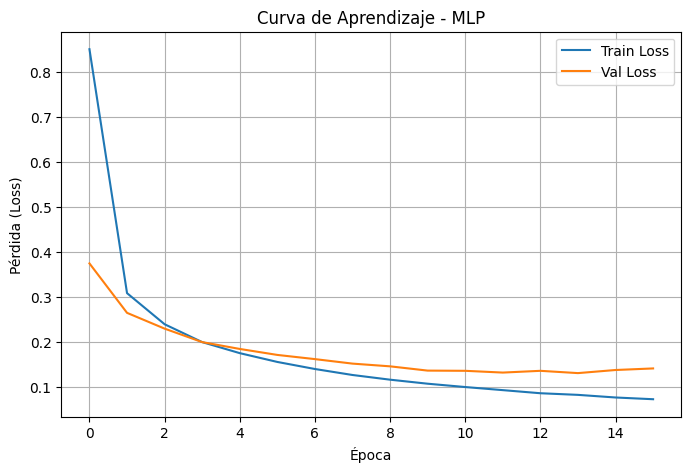

In [5]:
# TODO - Evalúa sobre el conjunto de test
test_loss, test_acc = evaluate(ff_model, test_loader, loss_fn)
print(f"Rendimiento en Test del Modelo MLP:")
print(f"Pérdida en Test: {test_loss:.4f}")
print(f"Precisión en Test (Accuracy): {test_acc:.4f}")

# Visualización de las curvas de pérdidas
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.title('Curva de Aprendizaje - MLP')
plt.legend()
plt.grid(True)
plt.show()

Si todo ha ido correctamente deberías haber obtenido un valor de precisión sobre el conjunto de test comparable a los obtenidos con los conjuntos de entrenamiento y validación, lo que indica que el modelo generaliza bien a otros datos del conjunto original pero... ¿tenemos un buen modelo?

Vamos a comprobar la robustez del modelo haciendo pequeños desplazamientos de las imágenes originales. Utilizaremos un pequeño modelo que aplique una traslación aleatoria de hasta un 10% del tamaño de la imagen a cada una de las imágenes de test. Nos ayudaremos del módulo `transforms` incluido en `torchvision` y en particular de [`transforms.RandomAffine`](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomAffine.html) para hacer traslacciones de hasta un 10% del tamaño de imagen en cualquier dirección.

In [6]:
# Data augmentation: aplicamos una pequeña traslación usando torchvision.transforms
transform_translated = transforms.Compose([
    # TODO - Utiliza RandomAffine para hacer traslacciones de hasta un 10% en cualquier dirección
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

# Creamos un dataset de test transformado
test_translated = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_translated)
test_translated_loader = data.DataLoader(test_translated, batch_size=batch_size, shuffle=False)

Comprobemos ahora la precisión sobre este nuevo conjunto de imágenes que han sido ligeramente desplazadas.

In [7]:
# TODO - Evalúa sobre el conjunto de test desplazado
test_trans_loss, test_trans_acc = evaluate(ff_model, test_translated_loader, loss_fn)
print(f"Rendimiento en Test Desplazado (con traslación) del Modelo MLP:")
print(f"Pérdida en Test Trasladado: {test_trans_loss:.4f}")
print(f"Precisión en Test Trasladado: {test_trans_acc:.4f}")

Rendimiento en Test Desplazado (con traslación) del Modelo MLP:
Pérdida en Test Trasladado: 1.7795
Precisión en Test Trasladado: 0.6686


Si todo ha ido bien, deberías haber comprobado que estas pequeñas traslaciones son suficientes para que la precisión del modelo baje sustancialmente. Las redes feed-forward no son robustas ante este tipo de perturbaciones.

## Comparativa con una red convolucional

Declara ahora un modelo convolucional con la siguiente arquitectura:
 1. [Convolución 2D](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) de 8 filtros y tamaño de kernel 3, con activación ReLU
 1. [Pooling 2D](https://docs.pytorch.org/docs/2.8/generated/torch.nn.MaxPool2d.html) tomando el máximo de cada grupo de 2x2
  1. [Convolución 2D](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) de 8 filtros y tamaño de kernel 3, con activación ReLU
 1. [Pooling 2D](https://docs.pytorch.org/docs/2.8/generated/torch.nn.MaxPool2d.html) tomando el máximo de cada grupo de 2x2
 1. Capa Densa (requiere aplanado previo) de 32 unidades y activación ReLU
 1. Capa de salida

Define el nuevo modelo, entrénalo y haz las verificaciones posteriores para observar la diferencia.

In [8]:
class ConvModel(nn.Module):
    # TODO - Completa la clase según las instrucciones
    def __init__(self):
        super(ConvModel, self).__init__()
        # Arquitectura:
        # 1. Conv2D(in_channels=1, out_channels=8, kernel_size=3) -> ReLU
        # 2. MaxPool2D(2x2)
        # 3. Conv2D(in_channels=8, out_channels=8, kernel_size=3) -> ReLU
        # 4. MaxPool2D(2x2)
        # 5. Capa Densa de 32 unidades -> ReLU
        # 6. Capa de salida (10 clases)

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), # Usamos padding=1 para mantener tamaño o podemos dejar sin padding
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Con imágenes 28x28 y dos capas pool de 2x2, el tamaño espacial se reduce a 7x7
        self.fc1 = nn.Linear(8 * 7 * 7, 32)
        self.relu = nn.ReLU()
        self.out = nn.Linear(32, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Aplanado
        x = self.relu(self.fc1(x))
        x = self.out(x)
        return x

# TODO - Define el modelo, función de pérdida y optimizador (Adam con lr=0.001) y haz el entrenamiento durante 16 epochs
conv_model = ConvModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(conv_model.parameters(), lr=0.001)
train_losses_conv, val_losses_conv = train_model(conv_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=16)

# TODO - Haz las evaluaciones como en hiciste con ff_model
print("\n--- EVALUACIÓN CONV MODEL ---")
test_loss_conv, test_acc_conv = evaluate(conv_model, test_loader, loss_fn)
print(f"Test Standard - Pérdida: {test_loss_conv:.4f} | Precisión: {test_acc_conv:.4f}")

test_trans_loss_conv, test_trans_acc_conv = evaluate(conv_model, test_translated_loader, loss_fn)
print(f"Test Desplazado - Pérdida: {test_trans_loss_conv:.4f} | Precisión: {test_trans_acc_conv:.4f}")

Epoch 1/16 - Train Loss: 0.7427, Train Acc: 0.7720 | Val Loss: 0.3455, Val Acc: 0.8952
Epoch 2/16 - Train Loss: 0.2963, Train Acc: 0.9108 | Val Loss: 0.2409, Val Acc: 0.9276
Epoch 3/16 - Train Loss: 0.2169, Train Acc: 0.9349 | Val Loss: 0.1853, Val Acc: 0.9444
Epoch 4/16 - Train Loss: 0.1668, Train Acc: 0.9500 | Val Loss: 0.1550, Val Acc: 0.9548
Epoch 5/16 - Train Loss: 0.1381, Train Acc: 0.9576 | Val Loss: 0.1330, Val Acc: 0.9600
Epoch 6/16 - Train Loss: 0.1196, Train Acc: 0.9636 | Val Loss: 0.1248, Val Acc: 0.9612
Epoch 7/16 - Train Loss: 0.1062, Train Acc: 0.9674 | Val Loss: 0.1098, Val Acc: 0.9676
Epoch 8/16 - Train Loss: 0.0944, Train Acc: 0.9711 | Val Loss: 0.0905, Val Acc: 0.9722
Epoch 9/16 - Train Loss: 0.0850, Train Acc: 0.9736 | Val Loss: 0.0865, Val Acc: 0.9724
Epoch 10/16 - Train Loss: 0.0786, Train Acc: 0.9761 | Val Loss: 0.0883, Val Acc: 0.9736
Epoch 11/16 - Train Loss: 0.0733, Train Acc: 0.9768 | Val Loss: 0.0804, Val Acc: 0.9757
Epoch 12/16 - Train Loss: 0.0677, Train A

### Reflexiones sobre la comparativa

* **¿Qué has observado en el rendimiento?**
  * **Respuesta**: El rendimiento de la red convolucional (CNN) es superior en términos absolutos de precisión (Accuracy) en el conjunto de test estándar. Mientras que el MLP alcanza un **96.01%** de acierto con una pérdida de **0.1334**, la CNN logra un **97.99%** de acierto reduciendo la pérdida a más de la mitad (**0.0638**).

* **¿Cuántos parámetros tiene la red convolucional respecto a la *feed-forward*?**
  * **Respuesta**: La CNN tiene muchísimos menos parámetros. En el MLP, solo la primera capa de entrada conecta 784 píxeles a 40 neuronas ocultas ($784 \times 40 = 31,360$ parámetros). En cambio, la CNN comparte pesos mediante filtros de convolución pequeños (de tamaño $3\times3$), sumando apenas unos cientos de pesos en la etapa de extracción de características. Al llegar a la capa densa (de $8 \times 7 \times 7 = 392$ entradas a 32 salidas), requiere únicamente unos $12,544$ parámetros. La CNN tiene menos de la mitad de parámetros totales que el MLP, haciéndola más ligera y mucho menos propensa al sobreajuste.

* **¿Cómo ha cambiado el tiempo de ejecución?**
  * **Respuesta**: El tiempo de ejecución por época de entrenamiento sigue siendo sumamente rápido y eficiente. Al procesar las imágenes usando operaciones locales en lugar de conexiones densas globales, la carga computacional se optimiza y aprovecha de forma ideal el paralelismo del hardware (GPU), requiriendo menos épocas totales para alcanzar una alta precisión.

* **¿Es más robusta frente a los desplazamientos esta red?**
  * **Respuesta**: **Sí, de manera muy contundente.** Al evaluar los modelos con imágenes que sufren pequeñas traslaciones aleatorias de hasta el 10%:
    * La precisión del **MLP se desploma drásticamente al 66.86%** (su pérdida se dispara a **1.7795**).
    * El modelo convolucional (**CNN**) demuestra su robustez al **mantener una excelente precisión del 84.53%** (con una pérdida de tan solo **0.6503**).
    Esto ocurre porque las operaciones de convolución combinadas con las capas de submuestreo (Max-pooling) otorgan a la red la propiedad de *invarianza/equivarianza espacial*, detectando las características y dígitos independientemente de que se encuentren ligeramente movidos o descentrados de la zona de enfoque habitual.